# Notebook Native Agent — Kaggle Demo

This notebook demonstrates a notebook-native coding assistant that can understand natural-language cells, reuse live notebook context, propose Python code, and safely auto-run eligible code.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/danisluk/notebook-native-agent-demo/notebook_native_agent.config.json
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/openai.config.json
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/README.md
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/PROJECT_DESCRIPTION.md
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/requirements.txt
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/tips.csv
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/notebook_native_agent/agent_inspectors.py
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/notebook_native_agent/registry.py
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/notebook_native_agent/handler.py
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/notebook_native_agent/display.py
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/notebook_native_agent/utils.py
/kaggle/input/datasets/danisluk/notebook-native-agent-demo/noteboo

In [2]:
import os
import sys
import shutil
from pathlib import Path

# Find the attached Kaggle dataset folder that contains the package.
candidates = [
    p for p in Path("/kaggle/input").rglob("notebook_native_agent")
    if p.is_dir()
]

if not candidates:
    raise FileNotFoundError("Could not find notebook_native_agent package under /kaggle/input.")

PACKAGE_SRC = candidates[0]
SRC = PACKAGE_SRC.parent
DST = Path("/kaggle/working/notebook-native-agent-demo")

if DST.exists():
    shutil.rmtree(DST)

shutil.copytree(SRC, DST)

sys.path.insert(0, str(DST))
os.chdir(DST)

print("Project copied to:", DST)
print("Current working directory:", Path.cwd())

Project copied to: /kaggle/working/notebook-native-agent-demo
Current working directory: /kaggle/working/notebook-native-agent-demo


## Configuration

The demo uses two JSON config files:

- `notebook_native_agent.config.json` controls runtime behavior: auto-execution, fallback mode, context display, repair retry, etc.
- `openai.config.json` controls role-specific model settings: interpreter, summarizer, brain, repair, and error review.

The next cell is optional. You can edit it if you want to override the defaults.

In [3]:
import json
from pathlib import Path

PROJECT_DIR = Path.cwd()

runtime_config_path = PROJECT_DIR / "notebook_native_agent.config.json"
openai_config_path = PROJECT_DIR / "openai.config.json"

runtime_config = {
    "name": "Notebook Native Agent",
    "auto_execute": True,
    "allow_fallback_codegen": False,
    "use_model_classifier": False,
    "echo_context": True,
    "max_context_items": 10,
    "max_repr_chars": 200,
    "allow_repair_retry": True,
    "max_auto_repair_attempts": 1,
    "raise_on_auto_exec_failure": False,
    "max_error_chars": 1600,
    "assist_on_python_error": True,
}

openai_config = {
    "classifier": {
        "model": "gpt-5.4-nano",
        "reasoning_effort": "minimal",
        "verbosity": "low",
    },
    "interpreter": {
        "model": "gpt-5.4-mini",
        "reasoning_effort": "low",
        "verbosity": "low",
    },
    "summarizer": {
        "model": "gpt-5.4-mini",
        "reasoning_effort": "low",
        "verbosity": "low",
    },
    "brain": {
        "model": "gpt-5.4-mini",
        "reasoning_effort": "medium",
        "verbosity": "medium",
    },
    "repair": {
        "model": "gpt-5.4-mini",
        "reasoning_effort": "medium",
        "verbosity": "low",
    },
    "python_error_review": {
        "model": "gpt-5.4-mini",
        "reasoning_effort": "medium",
        "verbosity": "low",
    },
}

runtime_config_path.write_text(
    json.dumps(runtime_config, indent=2),
    encoding="utf-8",
)

openai_config_path.write_text(
    json.dumps(openai_config, indent=2),
    encoding="utf-8",
)

print(f"Wrote: {runtime_config_path}")
print(f"Wrote: {openai_config_path}")

Wrote: /kaggle/working/notebook-native-agent-demo/notebook_native_agent.config.json
Wrote: /kaggle/working/notebook-native-agent-demo/openai.config.json


## Load Kaggle Secret

In [4]:
import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["OPENAI_API_KEY"] = user_secrets.get_secret("OPENAI_API_KEY")

## Start the agent

After this cell runs, you can write either normal Python cells or natural-language request cells.

In [10]:
from notebook_native_agent import start_agent, stop_agent, agent_status, agent_symbols, pause_agent, resume_agent, get_state

start_agent()

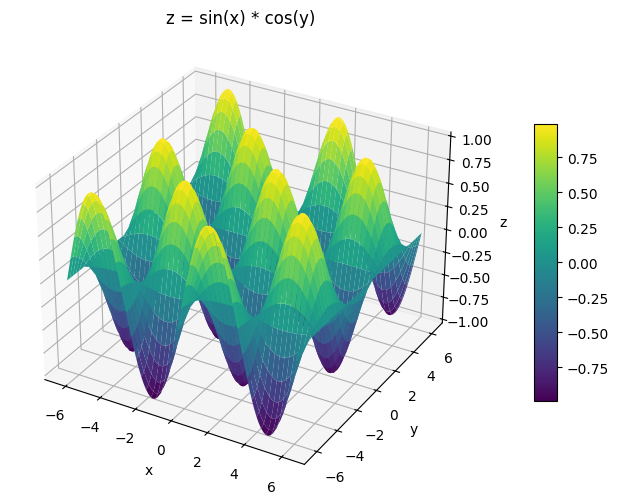

In [11]:
plot this: z = sin(x) * cos(y) 

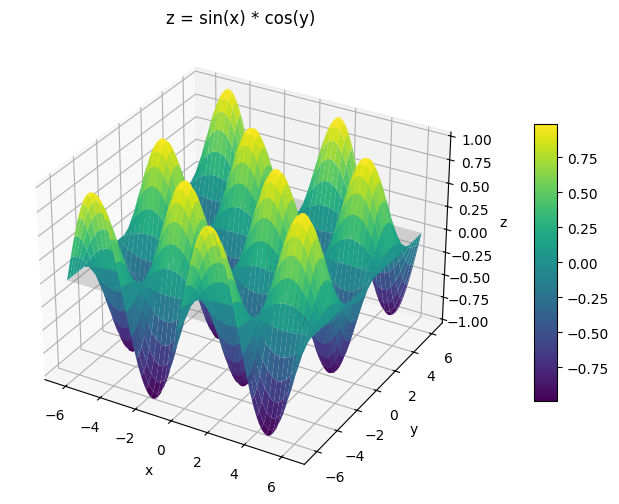

In [12]:
add the plan z = 0

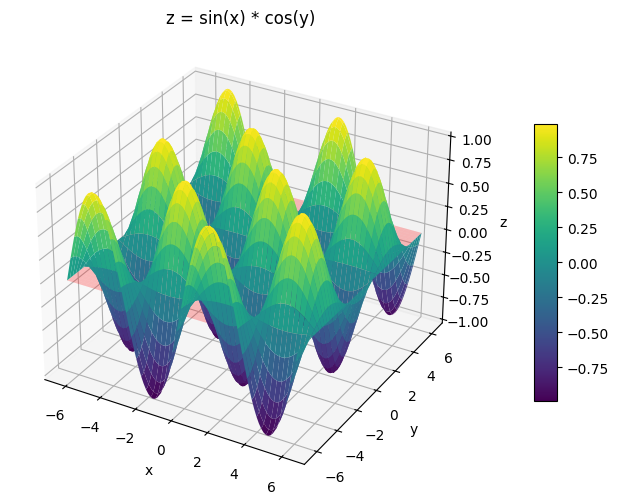

In [13]:
make it red 

In [ ]:
agent_status()

In [ ]:
agent_symbols()